In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("./src")
from analysis import *

In [3]:
italy_df = pd.read_csv("./data/processed/serie_a_final_standings.csv")
england_df = pd.read_csv("./data/processed/england_top_league_standings.csv")
germany_df = pd.read_csv("./data/processed/germany_bundesliga_standings.csv")
spain_df = pd.read_csv("./data/processed/spain_la_liga_standings.csv")
france_df = pd.read_csv("./data/processed/france_ligue1_standings.csv")

print(italy_df.shape)
print(england_df.shape)
print(germany_df.shape)
print(spain_df.shape)
print(france_df.shape)

(1455, 14)
(1691, 15)
(1114, 15)
(1464, 16)
(1554, 16)


In [4]:
france_df.head()

,Pos,Team,Pld,W,D,L,GF,GA,GAv,Pts,Qualification or relegation,season,GD,BP,PPG,City
0,1,Roubaix-Tourcoing,38,24,5,9,71,47,1.511,53,NaN,1946/47,24,NaN,NaN,Roubaix
1,2,Reims,38,22,5,11,72,40,1.800,49,NaN,1946/47,32,NaN,NaN,Reims
2,3,Strasbourg,38,21,7,10,79,50,1.580,49,NaN,1946/47,29,NaN,NaN,Strasbourg
3,4,Lille,38,20,7,11,89,52,1.712,47,NaN,1946/47,37,NaN,NaN,Lille
4,5,Stade Français,38,19,8,11,72,58,1.241,46,NaN,1946/47,14,NaN,NaN,Paris


# Teams and cities dominance in the Major European Leagues

The last round of the 2025-26 Italian Serie A league has been an upsetting day for Juentus and AC Milan, two of the most celebrated and successful teams of the Italian league. The final standing saw Inter winning the league but it was the only team of the so-called "strisciate" to finish in the first forth places of the table and so earning a spot for the 2026-27 Europe Champions League. Commentators were left asking themselves, how rare was that only one of these teams finished in the top four spots in the final standing. I was curious as well, as most of the Italian football fans, we see Juventus, Inter and Milan as a kind of gang for themselves: the bossy, if you're not a fan of one of the teams, owner of the Serie A (and their referees: fans are happy to think that if teams are so successful is because they also are helped by referees. And luck. And deities. And we can go on with the list).

So I decided to have a look to Italian Serie A final standings in the last 80 years, from season 1946 onward, i.e. after the second world war, to see if this "felt" domincance is fact based or is another fan hallucination. But even if we will find this is not true, we can't change our mind anyway: that's the rule of every football fan.

But every time I start with a simple quest involving data, I also end up asking more question and, in this case, was "what about other countries?". I am preatty sure Italian football has been dominated by these three teams, but is the same in the rest of Europe? So I also collected the data for England, Spain, Germany and France to see if their pattern looked different or not.

Sometimes, the best Data Science projects starts with strong unfounded opinion, prejudices we carry on with us and never bother to confirm them with any data. That's the life we enjoy. In this case, I am sure Italian football has been dominated by the three strisciate, in the ways I have explained earlier, but what about other leagues? That's rely mostly on my memory that, of course, do not cover eighty seasons and, from what I can sense, if you ask me if there are dominant teams in England, Spain, Germany and France like in Italy i would bet: 
 - England: not sure. I would say Manchester United, Man City (but I know their success is quite recent as they were considered the city ugly duckling), Liverpool, maybe Arsenal. I also remember the legendary Nottingham Forest winning what was the old Champions League in my first european final I ever watched on TV versus Hamburger SV. By the way, they both ended up to be, for different reasons, teams that I enjoyed support.
 - Spain: that is easy as, for me, there are only Barcelona and Real Madrid, with Athletico Madrid being a far third.
 - Germany: Bayern Munich. In my mind, Bayern owns the Bundesliga and they keep their keys close to their BMW ones. They decide when it opens, closes, if the weather is good to play and the color of each other teams shirts. Other teams sporadically show up when your team is playing agains them and you tell to yourself - "oh, Bayer allowed them to have a day out, how nice". Aside Hamburg, I also know Hamburger SV (they were Europe Champions beating Juventus in one of my best day in football), VfB Stuttgart (they played against Napoli in the UEFA Cup Final in a day that topped Juventus vs Hamburger), Borussia Dortmund (Jürgen Klopp), FC St. Pauli (the coolest team in the world), Hertha BSC and FC Union Berlin because I lived in Berlin. But they are irrelevant with respect to Bayern Munich success
 - France: Paris Saint-Germain FC in the recent years for sure. Before, I have memories of OM Marseille and Saint-Étienne (the club in which Michel Platini was the leader). But in terms of dominance, I proud myself to know anything and curious to see what's their history.

 Now the I set the starting point, let's collect the data and see what we can understand.

## The data sources: Wikipedia

The easiest way to retrieve the data I needed, i.e. the final tables of each league, was to scrape the Wikipedia pages of each league seasons. There is a dedicated notebook describing the whole process, just a few words of the major point you need to know if you want to do by yourself.
- I went for the english version of all leagues. The link format may change over time as, for example, the English League was first called First Division (`{year}–{yy}_Football_League_First_Division`) and then change name to the current Premier League (`{year}–{yy}_Premier_League`);
- Tables inside each webpage are mostly consistent except some cases where columns where added at a later stage (e.g. `AVg` not always present in each season)
- Team names might change depending on the year (e.g. `AC Milan` vs `Milan`, `Inter Milan` vs `Internazionale`)
- 1996-97 season for Spanish La Liga has a malformed HTML table with a corrupted rowspan attribute.
- German Bundesliga starts at season 1963/64, the first single division highest tier. Before, it was handled differently, because they are German and we are not surprised. As we want to analyse the top 4 teams for each country, the easiest way was considering German Bundesliga starting from that season onward. Could I make a different choice? Yes, but it was easier this way.

Wikipedia community is fantastic and I think they deserve all the possible praises. It took some time to clean a little bit the data and understand why the scraping was, somtimes, failing but is for free. And reliable. And if you have strong criticism, start your own project and show you're better. So, for me, a shout out to Wikipedia!

Alternatives to Wikipedia that I also considered were `worldfootball.net` and `football-data.co.uk` but they were more challenging, the first, or did not cover all seasons I wanted the latter. 


## Italian Serie A. A League of Two Cities.

"*It was the best of times (for Juventus, Inter and Milan fans), it was the worst of times (the others including me)*"

It's always best practice to start from the beginning, unless you are [Sergio Leone](https://en.wikipedia.org/wiki/Once_Upon_a_Time_in_America), [Michel Gondry](https://en.wikipedia.org/wiki/Eternal_Sunshine_of_the_Spotless_Mind), [Akira Kurosawa](https://en.wikipedia.org/wiki/Rashomon) or any other great artist who can masterfully manage the art of non linear narravive. Our first question was very clear precise: "is it an anomaly that just one team, between Juventus, Inter and Milan, finished in the first top four spots at the end of the season?". It's well known that these three clubs represent the hegemonic powers in Italian Serie A having won 62 Serie A titles in the last 80 seasons, close to the $80\%$ of the overall number of scudetto, while the remaining 18 titles where splitted between 9 other clubs. 

In [5]:
(compute_league_winners(italy_df)['Team']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'Team', 'count': 'Titles'})
)

,Team,Titles
0,Juventus,30
1,Milan,16
2,Inter Milan,16
3,Torino,4
4,Napoli,4
5,Fiorentina,2
6,Lazio,2
7,Roma,2
8,Bologna,1
9,Cagliari,1


That's really a tale of two cities: Torino and Milano. The first one ammassed a total of 34 titles combining exactly the $80\%$ of the total, the latter trailing at 32, while other seven cities have to share 14 titles.

In [6]:
(compute_league_winners(italy_df)['City']
 .value_counts()
 .reset_index()
 .rename(columns={'index': 'City', 'count': 'Titles'})
)

,City,Titles
0,Torino,34
1,Milano,32
2,Roma,4
3,Napoli,4
4,Firenze,2
5,Bologna,1
6,Cagliari,1
7,Verona,1
8,Genova,1


Just with these share numbers, the dominance is crystal clear. But what about the top 4 spots? Let's build a table computing the results of the strisciate for each season after WWII. 

In [7]:
strisciate_df = (compute_dominant_teams(italy_df, ['Juventus', 'Inter Milan', 'Milan'])
 .rename(columns={'number_of_dominant': 'n. of strisciate', 
                  'dominant': 'teams'})
)

strisciate_df[:5]

,season,n. of strisciate,teams,positions,points
0,1946/47,2,"[Juventus, Milan]","[2, 10, 4]","[53, 36, 50]"
1,1947/48,2,"[Juventus, Milan]","[3, 12, 2]","[49, 37, 49]"
2,1948/49,3,"[Juventus, Inter Milan, Milan]","[4, 2, 3]","[44, 55, 50]"
3,1949/50,3,"[Juventus, Inter Milan, Milan]","[1, 3, 2]","[62, 49, 57]"
4,1950/51,3,"[Juventus, Inter Milan, Milan]","[3, 2, 1]","[54, 59, 60]"


The table indicate that for season 1946/47, two of the striciate, Juventus and Milan, finished the season in the top 4, respectively second and forth places while Inter was in tenth place. Juventus scored 53 points, Milan 50 and Inter Milan 36 (the order in which to read `positions` and `points` is `Juventus`, `Inter Milan` and `Milan` respectively). In season 1949/50, they topped the first three places with Juventus first, Inter Milan third, and Milan second place. 

Using the table we can compute a summary that will tell us in how many seasons all three clubs occupied one of the first four spots, which seasons two of them and, finally like this season, just one team finished in the first 4. 

In [8]:
(strisciate_df
 .value_counts("n. of strisciate")
 .sort_index(ascending=False)
 .reset_index()
 .rename(columns={"count": "total"})
)

,n. of strisciate,total
0,3,28
1,2,37
2,1,15


So, in just 15 seasons out of 80 considered, included the 2025-26, just one strisciata ended up in the first top 4, leaving the remaining two in a lower position. Less than $20\%" of the total, less than 1 in 5 seasons. Can we agree it is a sign of dominance? By the way, in eighty seasons, Juventus missed just one Serie A season, Milan two. Yes, I like it when I remind it that it was for a fraud case (in the case of Juventus and one occurence for Milan).

The following plot shows the temporal trend of the top 4 spot.

In [9]:
strisciate_df

,season,n. of strisciate,teams,positions,points
0,1946/47,2,"[Juventus, Milan]","[2, 10, 4]","[53, 36, 50]"
1,1947/48,2,"[Juventus, Milan]","[3, 12, 2]","[49, 37, 49]"
2,1948/49,3,"[Juventus, Inter Milan, Milan]","[4, 2, 3]","[44, 55, 50]"
3,1949/50,3,"[Juventus, Inter Milan, Milan]","[1, 3, 2]","[62, 49, 57]"
4,1950/51,3,"[Juventus, Inter Milan, Milan]","[3, 2, 1]","[54, 59, 60]"
...,...,...,...,...,...
75,2021/22,3,"[Juventus, Inter Milan, Milan]","[4, 2, 1]","[70, 84, 86]"
76,2022/23,2,"[Inter Milan, Milan]","[7, 3, 4]","[62, 72, 70]"
77,2023/24,3,"[Juventus, Inter Milan, Milan]","[3, 1, 2]","[71, 94, 75]"
78,2024/25,2,"[Juventus, Inter Milan]","[4, 2, 8]","[70, 81, 63]"


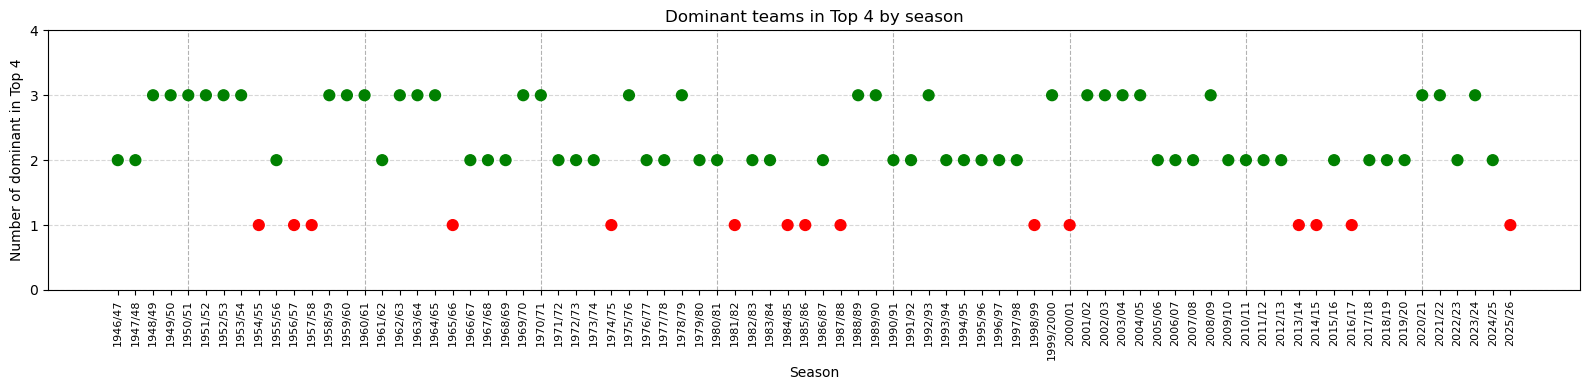

In [10]:
plot_dominant_teams(compute_dominant_teams(italy_df, ['Juventus', 'Inter Milan', 'Milan']))